# Predicción

In [ ]:
import os
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.models import load_model
from tensorflow.keras import layers, models, applications
from tensorflow.keras.preprocessing import image


In [ ]:
# Base model igual que en entrenamiento
base_model = applications.ResNet50(
    include_top=False,
    weights='imagenet',
    input_shape=(224, 224, 3)
)

base_model.trainable = False

# Modelo completo
model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),
    layers.Lambda(tf.keras.applications.resnet50.preprocess_input),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(512, activation='relu'),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(4, activation='softmax')
])

2026-04-21 01:14:53.347373: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8904
2026-04-21 01:14:53.399182: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory


1/1 [==============================] - 2s 2s/step

Imagen: WhatsApp Image 2026-04-21 at 12.04.41 AM.jpeg
Ranking de predicciones:
1° -> Clase: Papel_Carton (índice 3) | Prob: 0.9988 (99.88%)
2° -> Clase: Botellas_Plasticas (índice 0) | Prob: 0.0010 (0.10%)
3° -> Clase: Mecato (índice 2) | Prob: 0.0003 (0.03%)
4° -> Clase: Latas_Metalicas (índice 1) | Prob: 0.0000 (0.00%)


2026-04-21 01:14:54.323696: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory


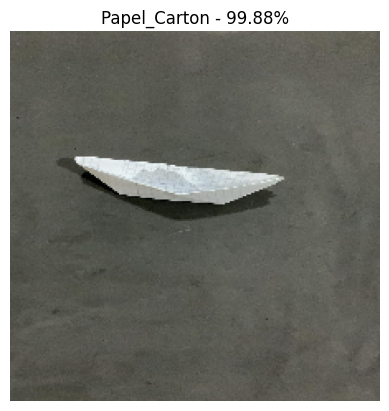

1/1 [==============================] - 0s 15ms/step

Imagen: WhatsApp Image 2026-04-20 at 11.32.17 PM.jpeg
Ranking de predicciones:
1° -> Clase: Mecato (índice 2) | Prob: 0.9991 (99.91%)
2° -> Clase: Botellas_Plasticas (índice 0) | Prob: 0.0008 (0.08%)
3° -> Clase: Latas_Metalicas (índice 1) | Prob: 0.0001 (0.01%)
4° -> Clase: Papel_Carton (índice 3) | Prob: 0.0000 (0.00%)


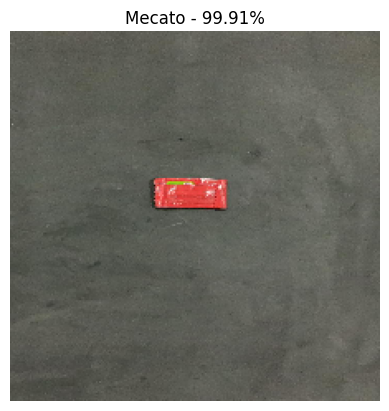

1/1 [==============================] - 0s 16ms/step

Imagen: WhatsApp Image 2026-04-20 at 10.43.21 PM.jpeg
Ranking de predicciones:
1° -> Clase: Papel_Carton (índice 3) | Prob: 0.9994 (99.94%)
2° -> Clase: Mecato (índice 2) | Prob: 0.0006 (0.06%)
3° -> Clase: Latas_Metalicas (índice 1) | Prob: 0.0000 (0.00%)
4° -> Clase: Botellas_Plasticas (índice 0) | Prob: 0.0000 (0.00%)


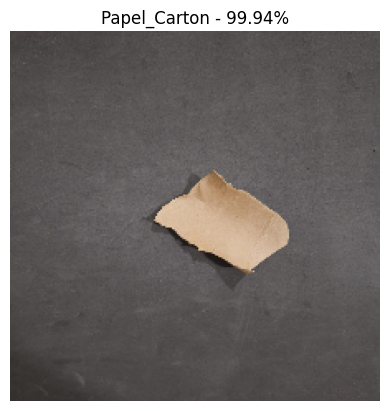

1/1 [==============================] - 0s 25ms/step

Imagen: WhatsApp Image 2026-04-20 at 11.07.54 PM.jpeg
Ranking de predicciones:
1° -> Clase: Mecato (índice 2) | Prob: 0.9999 (99.99%)
2° -> Clase: Papel_Carton (índice 3) | Prob: 0.0001 (0.01%)
3° -> Clase: Botellas_Plasticas (índice 0) | Prob: 0.0000 (0.00%)
4° -> Clase: Latas_Metalicas (índice 1) | Prob: 0.0000 (0.00%)


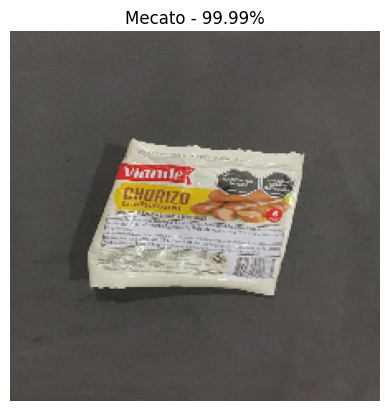

In [ ]:
# Ruta del modelo
model.load_weights('~/clasificador.keras')
# Ruta del directorio
dir_path = '~/prediccion-imagenes'

extensiones_validas = ('.jpg', '.jpeg', '.png')

class_names = ['Botellas_Plasticas', 'Latas_Metalicas', 'Mecato', 'Papel_Carton']

for archivo in os.listdir(dir_path):
    if archivo.lower().endswith(extensiones_validas):

        img_path = os.path.join(dir_path, archivo)

        # 1. Cargar imagen
        img = image.load_img(img_path, target_size=(224, 224))

        # 2. Convertir a array
        img_array = image.img_to_array(img)
        img_array_exp = np.expand_dims(img_array, axis=0)

        # 3. Predicción
        predicciones = model.predict(img_array_exp)[0]

        # 4. Ordenar probabilidades (de mayor a menor)
        indices_ordenados = np.argsort(predicciones)[::-1]

        print(f"\nImagen: {archivo}")
        print("Ranking de predicciones:")

        for i, idx in enumerate(indices_ordenados):
            prob = predicciones[idx]
            print(f"{i+1}° -> Clase: {class_names[idx]} (índice {idx}) | Prob: {prob:.4f} ({prob*100:.2f}%)")

        # 5. Clase ganadora
        top_idx = indices_ordenados[0]
        top_class = class_names[top_idx]
        top_prob = predicciones[top_idx]

        # 6. Mostrar imagen
        plt.imshow(img)
        plt.title(f"{top_class} - {top_prob*100:.2f}%")
        plt.axis('off')
        plt.show()